# Lightweight GRU (MGU + Additive Attention + CL) Model

## 1. Data Preprocessing

In [1]:
# Install missing packages (use magic install in Jupyter)
%pip install pandas numpy matplotlib seaborn scikit-learn --quiet

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Load dataset
data = pd.read_csv('/Dataset/5G_NIDD_Full.csv')

In [3]:
# Print the first few rows of the dataset
data.head()

,frame.time_relative,ip.src,ip.dst,ip.len,tcp.flags.syn,tcp.flags.ack,tcp.flags.push,tcp.flags.fin,tcp.flags.reset,tcp.flags.ece,...,eth.dst,ip.hdr_len,ip.ttl,tcp.window_size_value,tcp.hdr_len,udp.length,srcport,dstport,flow.id,label
0,0.000000,10.50.150.200,10.155.15.1,84,NaN,NaN,NaN,NaN,NaN,NaN,...,a8:6b:ad:fd:04:b4,20,58,0,0,0,0,0,10.50.150.200 10.155.15.1 0 0 1,Benign
1,0.839253,10.50.150.200,10.155.15.6,84,NaN,NaN,NaN,NaN,NaN,NaN,...,a8:6b:ad:fd:04:b4,20,58,0,0,0,0,0,10.50.150.200 10.155.15.6 0 0 1,Benign
2,0.898380,10.155.15.6,10.50.150.200,84,NaN,NaN,NaN,NaN,NaN,NaN,...,cc:48:3a:f9:0f:21,20,64,0,0,0,0,0,10.155.15.6 10.50.150.200 0 0 1,Benign
3,0.964037,10.50.150.200,10.155.15.0,84,NaN,NaN,NaN,NaN,NaN,NaN,...,a8:6b:ad:fd:04:b4,20,58,0,0,0,0,0,10.50.150.200 10.155.15.0 0 0 1,Benign
4,1.341397,10.155.15.0,109.105.109.207,216,NaN,NaN,NaN,NaN,NaN,NaN,...,cc:48:3a:f9:0f:21,20,64,0,0,196,49920,443,10.155.15.0 109.105.109.207 49920 443 17,Benign


In [4]:
# Print the info of each column
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6282130 entries, 0 to 6282129
Data columns (total 22 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   frame.time_relative    float64
 1   ip.src                 object 
 2   ip.dst                 object 
 3   ip.len                 int64  
 4   tcp.flags.syn          float64
 5   tcp.flags.ack          float64
 6   tcp.flags.push         float64
 7   tcp.flags.fin          float64
 8   tcp.flags.reset        float64
 9   tcp.flags.ece          float64
 10  ip.proto               int64  
 11  eth.src                object 
 12  eth.dst                object 
 13  ip.hdr_len             int64  
 14  ip.ttl                 int64  
 15  tcp.window_size_value  int64  
 16  tcp.hdr_len            int64  
 17  udp.length             int64  
 18  srcport                int64  
 19  dstport                int64  
 20  flow.id                object 
 21  label                  object 
dtypes: float64(7), int

In [5]:
# Print the shape of the dataset
rows, columns = data.shape
rows_columns = "\n The dataset has %d rows and %d columns." % (rows, columns)
print(rows_columns)


 The dataset has 6282130 rows and 22 columns.


In [6]:
# Drop unnecessary columns
drop_columns = ['ip.src', 'ip.dst', 'eth.src', 'eth.dst', 'flow.id']
data = data.drop(columns=drop_columns)

In [7]:
# Identify Qualitative Attributes
qualitative_attributes = data.select_dtypes(include=['object', 'category']).columns.tolist()
print("Qualitative (categorical) attributes:", qualitative_attributes)

Qualitative (categorical) attributes: ['label']


In [8]:
# Identify Quantitative Attributes
quantitative_attributes = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Quantitative (numerical) attributes:", quantitative_attributes)

Quantitative (numerical) attributes: ['frame.time_relative', 'ip.len', 'tcp.flags.syn', 'tcp.flags.ack', 'tcp.flags.push', 'tcp.flags.fin', 'tcp.flags.reset', 'tcp.flags.ece', 'ip.proto', 'ip.hdr_len', 'ip.ttl', 'tcp.window_size_value', 'tcp.hdr_len', 'udp.length', 'srcport', 'dstport']


In [9]:
# Remove label from categorical for encoding
target_column = 'label'
categorical_features = [col for col in qualitative_attributes if col != target_column]

In [10]:
# Check for columns with missing values
data.isnull().sum()

frame.time_relative            0
ip.len                         0
tcp.flags.syn            4370609
tcp.flags.ack            4370609
tcp.flags.push           4370609
tcp.flags.fin            4370609
tcp.flags.reset          4370609
tcp.flags.ece            4370609
ip.proto                       0
ip.hdr_len                     0
ip.ttl                         0
tcp.window_size_value          0
tcp.hdr_len                    0
udp.length                     0
srcport                        0
dstport                        0
label                          0
dtype: int64

In [11]:
# Handle missing values using median and mode
for col in categorical_features:
    data[col] = data[col].fillna(data[col].mode()[0])

for col in quantitative_attributes:
    data[col] = data[col].fillna(data[col].median())

In [12]:
# Drop duplicate rows if any
data.drop_duplicates(inplace=True)

In [13]:
# One-Hot Encoding for Qualtitative Attributes (except target)
if categorical_features: # Check if there are any remaining categorical features
    onehot_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    encoded_data = onehot_encoder.fit_transform(data[categorical_features])
    encoded_categorical_cols = onehot_encoder.get_feature_names_out(categorical_features)
    encoded_categorical_data = pd.DataFrame(encoded_data, columns=encoded_categorical_cols, index=data.index)
    data = data.drop(columns=categorical_features)
    data = pd.concat([data  , encoded_categorical_data], axis=1)

In [14]:
# Standardize Quantitative Attributes
scaler = StandardScaler()
data[quantitative_attributes] = scaler.fit_transform(data[quantitative_attributes])

In [15]:
# Noise Injection (applied to training subset only)
NOISE_LEVEL = 0.0 

def inject_noise(X_array, noise_level, seed=42):
    """Randomly replace `noise_level` fraction of values in X_array
    with values sampled from the same array (feature-distribution-preserving)."""
    if noise_level <= 0.0:
        return X_array
    rng = np.random.default_rng(seed)
    X_noisy = X_array.copy()
    mask = rng.random(X_array.shape) < noise_level
    # Sample replacement values from the flat distribution of X_array
    flat = X_array.flatten()
    replacements = rng.choice(flat, size=mask.sum(), replace=True)
    X_noisy[mask] = replacements
    return X_noisy

print(f"Noise level set to: {NOISE_LEVEL*100:.1f}%")
if NOISE_LEVEL > 0.0:
    print("Noise will be injected into X_train after the train/val/test split.")
else:
    print("No noise applied — X_train will be used as-is.")

Noise level set to: 0.0%
No noise applied — X_train will be used as-is.


In [ ]:
print(data['label'].value_counts())
print(pd.read_csv('/Dataset/5G_NIDD_Full.csv')['label'].unique())  # check raw CSV before encoding

label
Benign            2834524
HTTPFlood          858100
UDPFlood           733760
SlowrateDoS        617151
SYNFlood            26458
TCPConnectScan      20373
SYNScan             20152
UDPScan             15949
ICMPFlood            2309
Name: count, dtype: int64
['Benign' 'SlowrateDoS' 'ICMPFlood' 'TCPConnectScan' 'UDPFlood' 'SYNFlood'
 'UDPScan' 'SYNScan' 'HTTPFlood']


In [ ]:
# Encode target variable (label) to integer
label_encoder = LabelEncoder()
data[target_column] = label_encoder.fit_transform(data[target_column])
print("Original label classes: ", label_encoder.classes_)

# Binary Classification: Normal (0) vs Attack (1)
BINARY_MODE = True 

if BINARY_MODE:
    # label 0 = Normal (largest class), all others = Attack
    # This works whether classes are strings or integers
    NORMAL_ENCODED_IDX = 0  # Normal is always encoded as 0 (alphabetically first)
    data[target_column] = (data[target_column] != NORMAL_ENCODED_IDX).astype(int)
    binary_classes = np.array(['Normal', 'Attack'])
    print(f"Binary mode ON — encoded class 0 → 0 (Normal), all others → 1 (Attack)")
    print("Binary class distribution:")
    print(data[target_column].value_counts().rename({0: 'Normal (0)', 1: 'Attack (1)'}).to_string())
else:
    binary_classes = np.array([str(c) for c in label_encoder.classes_])
    print("Multiclass mode — using original labels.")

Original label classes:  ['Benign' 'HTTPFlood' 'ICMPFlood' 'SYNFlood' 'SYNScan' 'SlowrateDoS'
 'TCPConnectScan' 'UDPFlood' 'UDPScan']
Binary mode ON — encoded class 0 → 0 (Normal), all others → 1 (Attack)
Binary class distribution:
label
Normal (0)    2834524
Attack (1)    2294252


    Label    Count
0  Normal  2834524
1  Attack  2294252


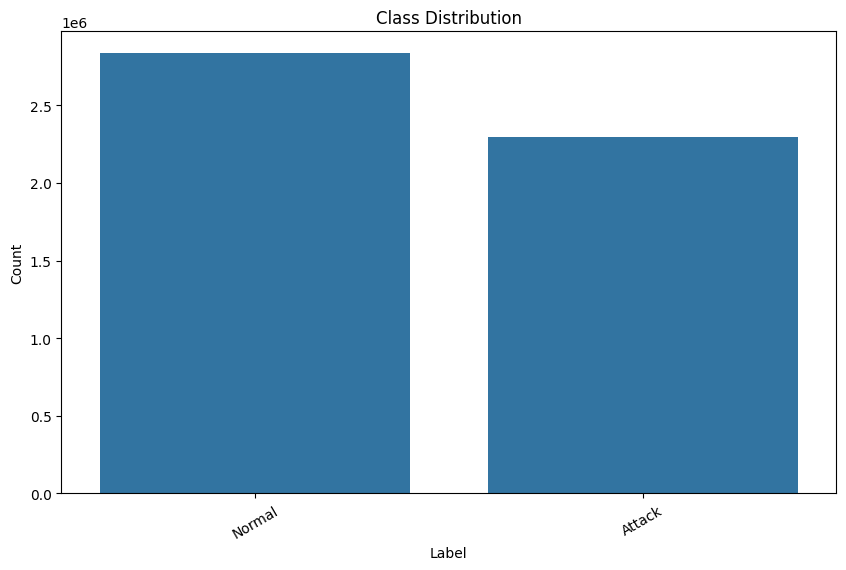

In [18]:
# Display the class distribution table
label_counts = data['label'].value_counts().sort_index()
if BINARY_MODE:
    normal_count = label_counts.get(0, 0)
    attack_count = label_counts.drop(index=0).sum() if 0 in label_counts.index else label_counts.sum()
    label_counts_table = pd.DataFrame({
        'Label': ['Normal', 'Attack'],
        'Count': [normal_count, attack_count]
    })
else:
    label_counts_table = pd.DataFrame({
        'Label': label_counts.index.astype(str),
        'Count': label_counts.values
    })
print(label_counts_table)

plt.figure(figsize=(10, 6))
sns.barplot(x='Label', y='Count', data=label_counts_table)
plt.xticks(rotation=30)
plt.title('Class Distribution')
plt.show()

In [19]:
# Choose the features and target variable
X = data.drop(columns=['label'])
y = data['label']

In [20]:
# Time-Series Split: Training (70%) and Test (30%)
# Data is sorted by natural order (no shuffling) to preserve temporal sequence

if 'X' not in locals() or 'y' not in locals():
    print("ERROR: X and y are not defined. Please run the previous cell first.")
    raise NameError("X and y must be defined before proceeding with time-series split.")

n = len(X)
train_end = int(n * 0.70)   # 70% for training
val_end   = int(n * 0.85)   # next 15% for validation
# remaining 15% is test

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val   = X.iloc[train_end:val_end]
y_val   = y.iloc[train_end:val_end]

X_test  = X.iloc[val_end:]
y_test  = y.iloc[val_end:]

print(f"Total samples : {n:,}")
print(f"Training set  : {X_train.shape[0]:,} ({X_train.shape[0]/n*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]:,}  ({X_val.shape[0]/n*100:.1f}%)")
print(f"Test set      : {X_test.shape[0]:,}  ({X_test.shape[0]/n*100:.1f}%)")
print()
print("Time-series split applied — data order preserved (no random shuffling).")

# ── Apply noise to training subset only ─────────────────────────────────
X_train_arr = X_train.values.copy()
X_train_arr = inject_noise(X_train_arr, NOISE_LEVEL, seed=42)
noisy_cells = int(NOISE_LEVEL * X_train_arr.size)
print(f"\nNoise injection on training set ({X_train.shape[0]:,} samples):")
print(f"  NOISE_LEVEL        : {NOISE_LEVEL*100:.1f}%")
print(f"  Feature values altered: {noisy_cells:,} / {X_train_arr.size:,}")
# Convert back to DataFrame so downstream code is unchanged
X_train = pd.DataFrame(X_train_arr, columns=X_train.columns, index=X_train.index)

Total samples : 5,128,776
Training set  : 3,590,143 (70.0%)
Validation set: 769,316  (15.0%)
Test set      : 769,317  (15.0%)

Time-series split applied — data order preserved (no random shuffling).

Noise injection on training set (3,590,143 samples):
  NOISE_LEVEL        : 0.0%
  Feature values altered: 0 / 57,442,288


## 2. Define the MGU + Additive Attention Model

In [21]:
import importlib

if importlib.util.find_spec('torch') is None:
    import subprocess, sys
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install',
        'torch', 'torchvision', 'torchaudio',
        '--index-url', 'https://download.pytorch.org/whl/cu121'
    ])
    print("PyTorch installed successfully.")
else:
    import torch
    print(f"PyTorch already installed — version {torch.__version__}, skipping.")


PyTorch already installed — version 2.10.0+cu128, skipping.


In [22]:
# Import libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

In [23]:
# Replay Buffer: Ring Buffer for Experience Replay
class ReplayBuffer:
    def __init__(self, capacity):
        self.capacity = capacity
        self.buffer = []

    def add(self, x, y):
        if len(self.buffer) >= self.capacity:
            self.buffer.pop(0)
        self.buffer.append((x.detach().cpu(), y.item()))

    def sample(self, batch_size, device):
        if len(self.buffer) == 0:
            return None, None
        batch = random.sample(self.buffer, min(batch_size, len(self.buffer)))
        x, y = zip(*batch)
        return torch.stack(x).to(device), torch.tensor(y).to(device)

# Initialize the buffer
replay_buffer = ReplayBuffer(capacity=500)

In [24]:
# MGU Cell: Minimal Gated Unit Cell - A lightweight alternative to GRU/LSTM
class MGUCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(MGUCell, self).__init__()
        self.hidden_size = hidden_size
        self.W_f = nn.Linear(input_size + hidden_size, hidden_size)
        self.W_h = nn.Linear(input_size + hidden_size, hidden_size)

    def forward(self, x, h_prev):
        combined = torch.cat([x, h_prev], dim=1)
        f = torch.sigmoid(self.W_f(combined))
        h_tilde = torch.tanh(self.W_h(combined))
        h_next = f * h_prev + (1 - f) * h_tilde
        return h_next

In [25]:
# MGU layer that processes sequences
class MGU(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(MGU, self).__init__()
        self.hidden_size = hidden_size
        self.cell = MGUCell(input_size, hidden_size)

    def forward(self, x):
        batch_size, seq_len, _ = x.size()
        h = torch.zeros(batch_size, self.hidden_size, device=x.device)

        outputs = []
        for t in range(seq_len):
            h = self.cell(x[:, t, :], h)
            outputs.append(h.unsqueeze(1))
        return torch.cat(outputs, dim=1)

In [26]:
class AdditiveAttention(nn.Module):
    """
    Bahdanau-style additive attention over a sequence of hidden states.

    Parameters
    ----------
    hidden_size : int
        Size of each hidden state vector from MGU.
    attention_size : int
        Internal projection size (default = hidden_size // 2 to save params).
    """
    def __init__(self, hidden_size, attention_size=None):
        super().__init__()
        if attention_size is None:
            attention_size = hidden_size // 2      # keeps param count small

        # Project hidden states into attention space
        self.W_h = nn.Linear(hidden_size, attention_size, bias=False)
        # Learnable context vector — what the model "looks for"
        self.v   = nn.Linear(attention_size, 1, bias=False)

    def forward(self, x):
        """
        x : [batch, seq_len, hidden_size]
        returns
            context : [batch, hidden_size]   weighted sum across time
            weights : [batch, seq_len]        attention weights (for inspection)
        """
        # Score each time step
        score = torch.tanh(self.W_h(x))          # [batch, seq_len, attention_size]
        score = self.v(score).squeeze(-1)         # [batch, seq_len]

        # Normalise scores → attention weights
        weights = F.softmax(score, dim=1)         # [batch, seq_len]

        # Weighted sum of hidden states
        context = torch.bmm(weights.unsqueeze(1), x).squeeze(1)  # [batch, hidden_size]
        return context, weights

In [27]:
class MGU_AdditiveAttention_Conv1D(nn.Module):
    def __init__(self, input_features, hidden_size, num_classes, attention_size=None):
        super().__init__()
        self.conv1     = nn.Conv1d(in_channels=input_features,
                                   out_channels=hidden_size,
                                   kernel_size=3, padding=1)
        self.bn        = nn.BatchNorm1d(hidden_size)  # BatchNorm for stability 
        self.mgu       = MGU(input_size=hidden_size, hidden_size=hidden_size)
        self.attention = AdditiveAttention(hidden_size, attention_size)
        self.dropout   = nn.Dropout(p=0.3)         # light regularisation
        self.fc        = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x: [batch, seq_len, features]
        x = x.permute(0, 2, 1)                    # [batch, features, seq_len]
        x = self.bn(F.relu(self.conv1(x)))        # [batch, hidden, seq_len]                          # Apply batch normalization
        x = x.permute(0, 2, 1)                    # [batch, seq_len, hidden]
        x = self.mgu(x)                           # [batch, seq_len, hidden]

        context, _ = self.attention(x)             # [batch, hidden]
        context    = self.dropout(context)
        out        = self.fc(context)             # [batch, num_classes]
        return out

## 3. Data Preparation for Sequence Modeling

In [28]:
""""
Convert flat data into sequences for temporal modeling

Arguments:
- X: Feature data (numpy array or pandas DataFrame)
- y: Labels (numpy array or pandas Series)
- seq_length: Number of time steps in each sequence

Returns:
- X_seq, y_seq: Sequenced data suitable for temporal models (numpy arrays)
"""
def create_sequences(X, y, seq_length=10):
    X_sequences = []
    y_sequences = []

    # Convert to numpy if needed
    if not isinstance(X, np.ndarray):
        X = X.values
    if not isinstance(y, np.ndarray):
        y = y.values

    for i in range(len(X) - seq_length + 1):
        X_sequences.append(X[i:i + seq_length])
        # Use the label of the last time step in the sequence
        y_sequences.append(y[i + seq_length - 1])

    return np.array(X_sequences), np.array(y_sequences)

## 4. Model Training

In [29]:
class FocalLoss(nn.Module):
    """
    Multiclass Focal Loss.

    Parameters
    ----------
    gamma : float
        Focusing parameter. 0 = standard CrossEntropy. Typical: 1–2 for tabular data.
    alpha : Tensor or None
        Per-class weights [num_classes]. Recommend None for first run.
    reduction : str
        'mean' | 'sum' | 'none'
    """
    def __init__(self, gamma=1.5, alpha=None, reduction='mean'):
        super().__init__()
        self.gamma     = gamma
        self.alpha     = alpha
        self.reduction = reduction

    def forward(self, logits, targets):
        ce_loss    = F.cross_entropy(logits, targets,
                                     weight=self.alpha,
                                     reduction='none')       # [batch]
        p_t        = torch.exp(-ce_loss)                     # [batch]
        focal_loss = (1.0 - p_t) ** self.gamma * ce_loss    # [batch]

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss

In [30]:
""""
Train MGU_AdditiveAttention_Conv1D with Focal Loss.

Arguments:
    model: The MGU model
    train_loader: DataLoader for training data
    val_loader: DataLoader for validation data
    epochs: Number of training epochs
    learning_rate: Learning rate for the optimizer
    device: Device to run the training on ('cpu' or 'cuda')
    gamma : float
    
    Focal Loss gamma. 0 = CrossEntropy. Use 1.5 for tabular/sequence data.
    Only increase to 2.0 if precision is still low after a full training run.
"""
def train_model(model, train_loader, val_loader, epochs=70, learning_rate=0.001, gamma=2.0, alpha=None,
                device='cpu'):
    import time
    start_time = time.time()

    model = model.to(device)
    criterion = FocalLoss(gamma=gamma, alpha=alpha, reduction='mean')
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

    train_losses = []
    val_losses = []
    train_accuracy = []
    val_accuracy = []

    # Early stopping
    best_val_loss = float('inf')
    patience_counter = 0
    PATIENCE = 10

    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            # Gradient clipping: prevents exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += y_batch.size(0)
            train_correct += (predicted == y_batch).sum().item()

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)

                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += y_batch.size(0)
                val_correct += (predicted == y_batch).sum().item()

        # Calculate metrics
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        train_acc = 100 * train_correct / train_total
        val_acc = 100 * val_correct / val_total

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accuracy.append(train_acc)
        val_accuracy.append(val_acc)

        scheduler.step()

        if (epoch + 1) % 5 == 0:
            print(f'Epoch [{epoch+1}/{epochs}]')
            print(f'Train Loss: {avg_train_loss:.4f}, Train Accuracy: {train_acc:.2f}%')
            print(f'Val Loss: {avg_val_loss:.4f}, Val Accuracy: {val_acc:.2f}%')
            print('-' * 50)

        # Early stopping check
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            torch.save(model.state_dict(), 'best_model.pt')  # Save the best weights
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f'Early stopping at epoch {epoch+1}')
                break
    
    # Load best weights before returning results
    model.load_state_dict(torch.load('best_model.pt'))
    print(f'Best model (val loss: {best_val_loss:.4f})')

    total_time = time.time() - start_time
    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accuracy': train_accuracy,
        'val_accuracy': val_accuracy,
        'training_time': total_time
    }

In [31]:
%pip install torchinfo
from torchinfo import summary

Note: you may need to restart the kernel to use updated packages.


In [32]:
# Hyperparameters
SEQ_LENGTH = 20  # Number of time steps in each sequence
HIDDEN_SIZE = 64  # Hidden size for MGU
CONV_CHANNELS = 32  # Number of Conv1D channels
ATTENTION_SIZE = 32     # Additive attention projection size (hidden_size // 2)
BATCH_SIZE = 256 # Batch size for DataLoader
EPOCHS = 70 # Number of training epochs
LEARNING_RATE = 0.001  # Learning rate for optimizer
FOCAL_GAMMA = 1.0    # Focal Loss gamma (0 = CrossEntropy, 1.5 = safe for tabular)

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Create sequences from the flat data
X_train_seq, y_train_seq = create_sequences(X_train, y_train, seq_length=SEQ_LENGTH)
X_val_seq, y_val_seq = create_sequences(X_val, y_val, seq_length=SEQ_LENGTH)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, seq_length=SEQ_LENGTH)

# Compute inverse-frequency alpha weights for Focal Loss (optional, can be set to None for uniform weighting)
num_classes = len(np.unique(y_train_seq))
class_counts = np.bincount(y_train_seq, minlength=num_classes).astype(np.float32)
class_counts = np.maximum(class_counts, 1)
alpha = 1.0 / np.sqrt(class_counts)
alpha = alpha / alpha.sum() * num_classes
alpha = torch.tensor(alpha, dtype=torch.float32)
print("Class alpha weights: ", alpha)

print(f"Training sequences shape: {X_train_seq.shape}")
print(f"Validation sequences shape: {X_val_seq.shape}")
print(f"Test sequences shape: {X_test_seq.shape}")

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_seq)
y_train_tensor = torch.LongTensor(y_train_seq)
X_val_tensor   = torch.FloatTensor(X_val_seq)
y_val_tensor   = torch.LongTensor(y_val_seq)
X_test_tensor  = torch.FloatTensor(X_test_seq)
y_test_tensor  = torch.LongTensor(y_test_seq)

# Create data loaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

# Initialize the new model
input_size  = X_train_seq.shape[2]
output_size = len(np.unique(y_train))

model = MGU_AdditiveAttention_Conv1D(
    input_features = input_size,
    hidden_size    = HIDDEN_SIZE,
    attention_size = ATTENTION_SIZE,
    num_classes    = output_size,
).to(device)

# Parameter counts
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nSummary of Model Architecture Details:")
summary(model,
        input_size=(BATCH_SIZE, SEQ_LENGTH, input_size),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

print(f"Total Parameters    : {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")
print(f"Non-trainable Params: {total_params - trainable_params:,}")

# ── Model Size (on-disk footprint of weights) ──────────────────────────
import io
buffer = io.BytesIO()
torch.save(model.state_dict(), buffer)
model_size_bytes = buffer.tell()
model_size_kb    = model_size_bytes / 1024
model_size_mb    = model_size_bytes / (1024 ** 2)
print(f"{'='*60}")
print(f"Model Size (state_dict): {model_size_bytes:,} bytes")
print(f"                       : {model_size_kb:.2f} KB")
print(f"                       : {model_size_mb:.4f} MB")
print(f"{'='*60}")

Using device: cuda
Class alpha weights:  tensor([0.8919, 1.1081])
Training sequences shape: (3590124, 20, 16)
Validation sequences shape: (769297, 20, 16)
Test sequences shape: (769298, 20, 16)

Summary of Model Architecture Details:
Total Parameters    : 21,986
Trainable Parameters: 21,986
Non-trainable Params: 0
Model Size (state_dict): 93,686 bytes
                       : 91.49 KB
                       : 0.0893 MB


In [33]:
# Elastic Weight Consolidation (EWC): Prevent catastrophic forgetting during training
def compute_fisher(model, dataloader, criterion, device):
    #Compute Fisher Information Matrix for EWC
    fisher = {n: torch.zeros_like(p) for n, p in model.named_parameters()}
    model.eval()

    for x, y in dataloader:
        x, y = x.to(device), y.to(device)
        model.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Gradient clipping for stability

        for n, p in model.named_parameters():
            if p.grad is not None:
                fisher[n] += p.grad.detach().clone().pow(2)

    for n in fisher:
        fisher[n] /= len(dataloader)

    return fisher

In [34]:
# Train the model
history = train_model(model=model,
                      train_loader=train_loader,
                      val_loader=val_loader,
                      epochs=EPOCHS,
                      learning_rate=LEARNING_RATE,
                      device=device)

training_time = history['training_time']
print(f"Total Training Time: {training_time:.2f} seconds ({training_time/60:.2f} minutes)")
print(f"Average Time per Epoch: {training_time/EPOCHS:.2f} seconds")

Epoch [5/70]
Train Loss: 0.0201, Train Accuracy: 96.96%
Val Loss: 0.1488, Val Accuracy: 58.91%
--------------------------------------------------
Epoch [10/70]
Train Loss: 0.0195, Train Accuracy: 97.01%
Val Loss: 0.1551, Val Accuracy: 58.99%
--------------------------------------------------
Epoch [15/70]
Train Loss: 0.0193, Train Accuracy: 97.02%
Val Loss: 0.1525, Val Accuracy: 58.91%
--------------------------------------------------
Early stopping at epoch 15
Best model (val loss: 0.1488)
Total Training Time: 4056.17 seconds (67.60 minutes)
Average Time per Epoch: 57.95 seconds


In [ ]:
import torch
torch.save(model, '/Source Code/lightweight_mguAttnCL_model.pth')
print("Model weights saved to 'lightweight_mguAttnCL_model.pth'")

Model weights saved to 'lightweight_mguAttnCL_model.pth'


### Continual Learning

In [36]:
# Freeze learned knowledge

# Initialize criterion and optimizer for continual learning
criterion = FocalLoss(gamma=FOCAL_GAMMA, alpha=alpha, reduction='mean')
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)

# Save old parameters
old_params = {n: p.clone().detach() for n, p in model.named_parameters()}

# Compute Fisher
fisher = compute_fisher(model, train_loader, FocalLoss(gamma=FOCAL_GAMMA, alpha=alpha.to(device)), device)

In [37]:
# Continual Learning Training Loop with ER + EWC

ewc_lambda = 1e-4
replay_weight = 0.5
continual_epochs = 10

# Ensure FocalLoss weight tensor is on the same device as the model
if getattr(criterion, "alpha", None) is not None:
    criterion.alpha = criterion.alpha.to(device)

model.train()

for epoch in range(continual_epochs):
    running_loss = 0.0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs_new = model(inputs)
        loss_new = criterion(outputs_new, labels)

        x_rep, y_rep = replay_buffer.sample(batch_size=inputs.size(0), device=device)
        if x_rep is not None:
            outputs_rep = model(x_rep)
            loss_rep = criterion(outputs_rep, y_rep)
        else:
            loss_rep = torch.tensor(0.0, device=device)

        ewc_loss = torch.tensor(0.0, device=device)
        for n, p in model.named_parameters():
            ewc_loss += (fisher[n] * (p - old_params[n]).pow(2)).sum()

        loss = loss_new + replay_weight * loss_rep + ewc_lambda * ewc_loss

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        for x, y in zip(inputs, labels):
            replay_buffer.add(x, y)

        running_loss += loss.item()

    print(f"CL Epoch {epoch+1}/{continual_epochs}: Loss: {running_loss / len(train_loader):.4f}")


CL Epoch 1/10: Loss: 0.0584
CL Epoch 2/10: Loss: 0.0579
CL Epoch 3/10: Loss: 0.0577
CL Epoch 4/10: Loss: 0.0575
CL Epoch 5/10: Loss: 0.0575
CL Epoch 6/10: Loss: 0.0574
CL Epoch 7/10: Loss: 0.0574
CL Epoch 8/10: Loss: 0.0573
CL Epoch 9/10: Loss: 0.0572
CL Epoch 10/10: Loss: 0.0572


## 5. Model Evaluation

In [39]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [40]:
# Evaluate model on a given DataLoader; returns preds, labels, probs, time
def evaluate_model(model, data_loader, device='cpu'):
    import time
    model.eval()
    all_preds  = []
    all_labels = []
    all_probs  = []

    start_time = time.time()

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs    = model(X_batch)
            probs      = torch.softmax(outputs, dim=1)   # class probabilities
            _, predicted = torch.max(outputs.data, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    inference_time = time.time() - start_time
    return np.array(all_preds), np.array(all_labels), np.array(all_probs), inference_time

# Evaluate on TRAINING set
train_preds, train_true, train_probs, train_inference_time = evaluate_model(
    model, train_loader, device)

print(f"\n{'='*60}")
print(f"Training Set Inference Summary:")
print(f"{'='*60}")
print(f"Total Inference Time  : {train_inference_time:.2f} seconds")
print(f"Number of Train Samples: {len(train_preds)}")
print(f"Average Time per Sample: {train_inference_time/len(train_preds)*1000:.4f} ms")
print(f"{'='*60}")

# Evaluate on TEST set
predictions, true_labels, test_probs, inference_time = evaluate_model(
    model, test_loader, device)

print(f"\n{'='*60}")
print(f"Test Set Inference Summary:")
print(f"{'='*60}")
print(f"Total Inference Time  : {inference_time:.2f} seconds")
print(f"Number of Test Samples: {len(predictions)}")
print(f"Average Time per Sample: {inference_time/len(predictions)*1000:.4f} ms")
print(f"{'='*60}")
# Aliases kept for backward-compatibility with later cells
y_test_bin  = true_labels
y_prob      = test_probs
y_train_bin = train_true
y_train_prob= train_probs



Training Set Inference Summary:
Total Inference Time  : 86.86 seconds
Number of Train Samples: 3590124
Average Time per Sample: 0.0242 ms

Test Set Inference Summary:
Total Inference Time  : 18.27 seconds
Number of Test Samples: 769298
Average Time per Sample: 0.0238 ms


### Classification Report

In [41]:
from sklearn.metrics import classification_report, accuracy_score

# Use binary_classes when BINARY_MODE=True, else original multiclass names
class_names_used = binary_classes if BINARY_MODE else label_encoder.classes_

print("\n" + "="*60)
print("Classification Report — TRAINING SET")
print("="*60)
print(classification_report(train_true, train_preds,
                            target_names=class_names_used))
print("Training Overall Accuracy: {:.2f}%".format(
      accuracy_score(train_true, train_preds) * 100))

print("\n" + "="*60)
print("Classification Report — TEST SET")
print("="*60)
print(classification_report(true_labels, predictions,
                            target_names=class_names_used))
print("Test Overall Accuracy: {:.2f}%".format(
      accuracy_score(true_labels, predictions) * 100))


Classification Report — TRAINING SET
              precision    recall  f1-score   support

      Normal       0.95      1.00      0.98   2178672
      Attack       1.00      0.93      0.96   1411452

    accuracy                           0.97   3590124
   macro avg       0.98      0.96      0.97   3590124
weighted avg       0.97      0.97      0.97   3590124

Training Overall Accuracy: 96.99%

Classification Report — TEST SET
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    419382
      Attack       1.00      1.00      1.00    349916

    accuracy                           1.00    769298
   macro avg       1.00      1.00      1.00    769298
weighted avg       1.00      1.00      1.00    769298

Test Overall Accuracy: 99.81%


### Confusion Matrix


 Confusion Matrix — TRAINING SET


,Normal,Attack
Normal,2173817,4855
Attack,103239,1308213


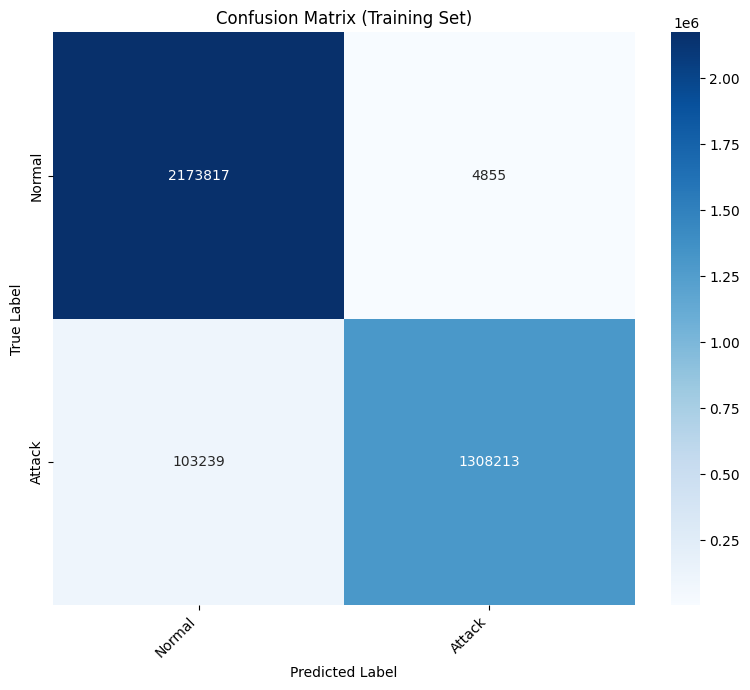


 Confusion Matrix — TEST SET


,Normal,Attack
Normal,418230,1152
Attack,325,349591


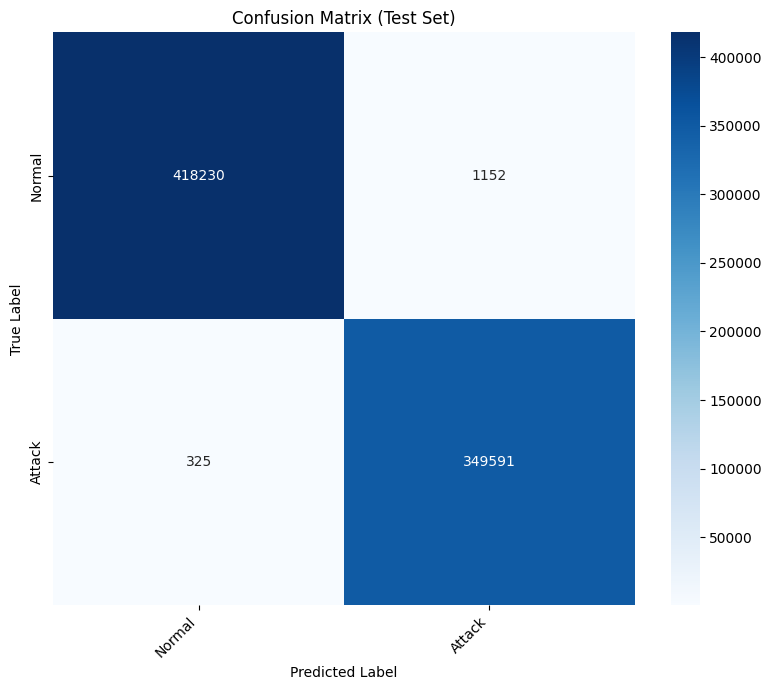

In [42]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(y_true, y_pred, class_names, title='Confusion Matrix'):
    cm      = confusion_matrix(y_true, y_pred)
    cm_data = pd.DataFrame(cm, index=class_names, columns=class_names)
    display(cm_data)

    plt.figure(figsize=(8, 7))
    sns.heatmap(cm_data, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

print("\n Confusion Matrix — TRAINING SET")
plot_confusion_matrix(train_true, train_preds,
                      binary_classes if BINARY_MODE else label_encoder.classes_,
                      title='Confusion Matrix (Training Set)')

print("\n Confusion Matrix — TEST SET")
plot_confusion_matrix(true_labels, predictions,
                      binary_classes if BINARY_MODE else label_encoder.classes_,
                      title='Confusion Matrix (Test Set)')


### ROC Curves & Precision-Recall Curves (Training & Test Sets)


=== ROC Curves — TRAINING SET ===


/tmp/ipykernel_57/652490529.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n)


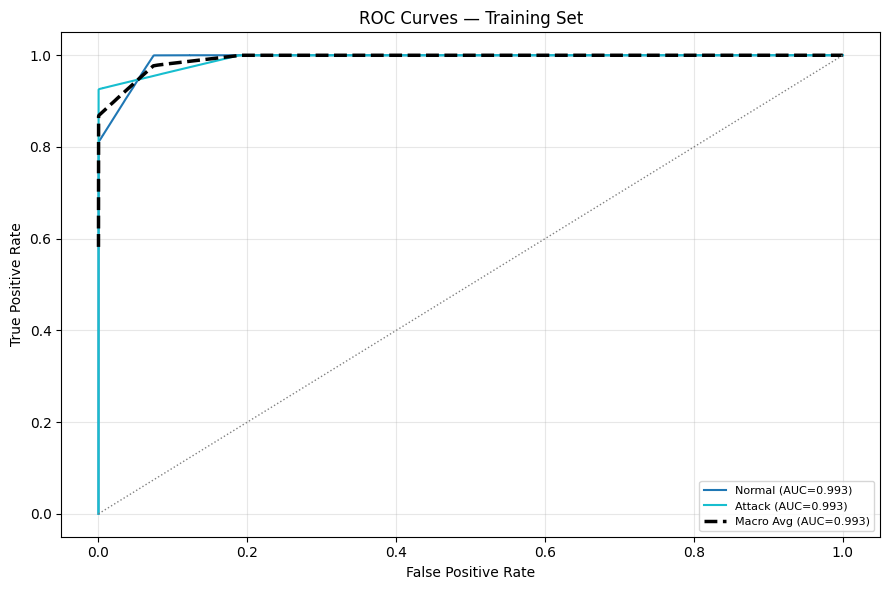

Macro ROC-AUC (Training Set): 0.9930

=== ROC Curves — TEST SET ===


/tmp/ipykernel_57/652490529.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n)


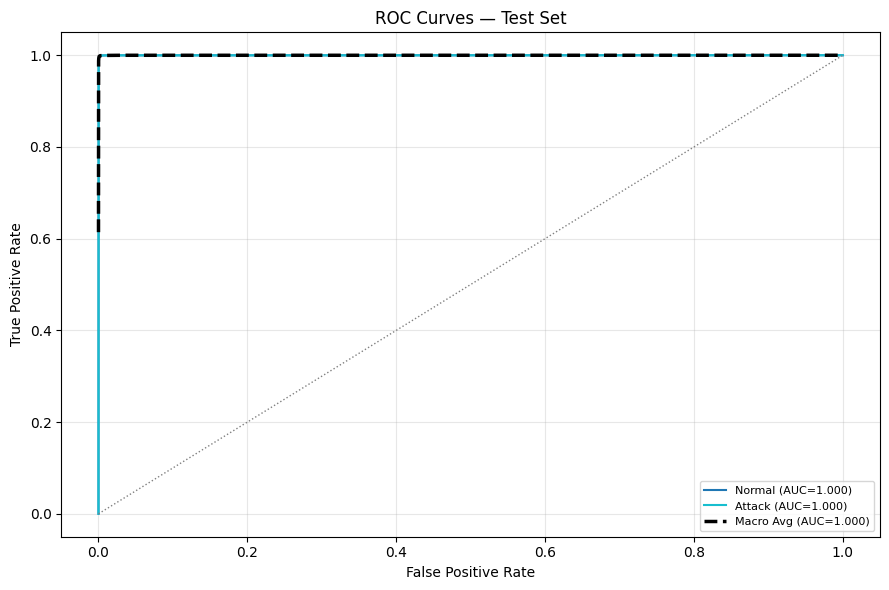

Macro ROC-AUC (Test Set): 1.0000


In [43]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

num_classes = 2 if BINARY_MODE else len(label_encoder.classes_)
class_names = binary_classes if BINARY_MODE else label_encoder.classes_

def binarize_labels(y_true, num_classes):
    """Handle binary vs multiclass binarization correctly."""
    if num_classes == 2:
        # For binary, manually create 2-column one-hot
        y_bin = np.zeros((len(y_true), 2), dtype=int)
        y_bin[:, 1] = np.array(y_true)
        y_bin[:, 0] = 1 - y_bin[:, 1]
        return y_bin
    else:
        return label_binarize(y_true, classes=list(range(num_classes)))

def plot_roc_curves(y_bin, y_prob_arr, class_names, split_name):
    """Plot per-class and macro-average ROC curves."""
    n = len(class_names)
    colors = plt.cm.get_cmap('tab10', n)
    fpr_dict, tpr_dict, roc_auc_dict = {}, {}, {}
    for i in range(n):
        fpr_dict[i], tpr_dict[i], _ = roc_curve(y_bin[:, i], y_prob_arr[:, i])
        roc_auc_dict[i] = auc(fpr_dict[i], tpr_dict[i])
    # Macro average
    all_fpr = np.unique(np.concatenate([fpr_dict[i] for i in range(n)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n):
        mean_tpr += np.interp(all_fpr, fpr_dict[i], tpr_dict[i])
    mean_tpr /= n
    roc_auc_macro = auc(all_fpr, mean_tpr)
    plt.figure(figsize=(9, 6))
    for i in range(n):
        plt.plot(fpr_dict[i], tpr_dict[i], color=colors(i), lw=1.5,
                 label=f'{class_names[i]} (AUC={roc_auc_dict[i]:.3f})')
    plt.plot(all_fpr, mean_tpr, 'k--', lw=2.5,
             label=f'Macro Avg (AUC={roc_auc_macro:.3f})')
    plt.plot([0, 1], [0, 1], 'gray', lw=1, linestyle=':')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curves — {split_name}')
    plt.legend(loc='lower right', fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f"Macro ROC-AUC ({split_name}): {roc_auc_macro:.4f}")
    return roc_auc_macro

# Binarize correctly for binary or multiclass
y_train_bin_oh = binarize_labels(train_true,  num_classes)
y_test_bin_oh  = binarize_labels(true_labels, num_classes)

print("\n=== ROC Curves — TRAINING SET ===")
roc_auc_train = plot_roc_curves(y_train_bin_oh, train_probs, class_names, 'Training Set')
print("\n=== ROC Curves — TEST SET ===")
roc_auc_test  = plot_roc_curves(y_test_bin_oh,  test_probs,  class_names, 'Test Set')

### Precision-Recall Curves & Macro PR-AUC


=== Precision-Recall Curves — TRAINING SET ===


/tmp/ipykernel_57/2376690815.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n)


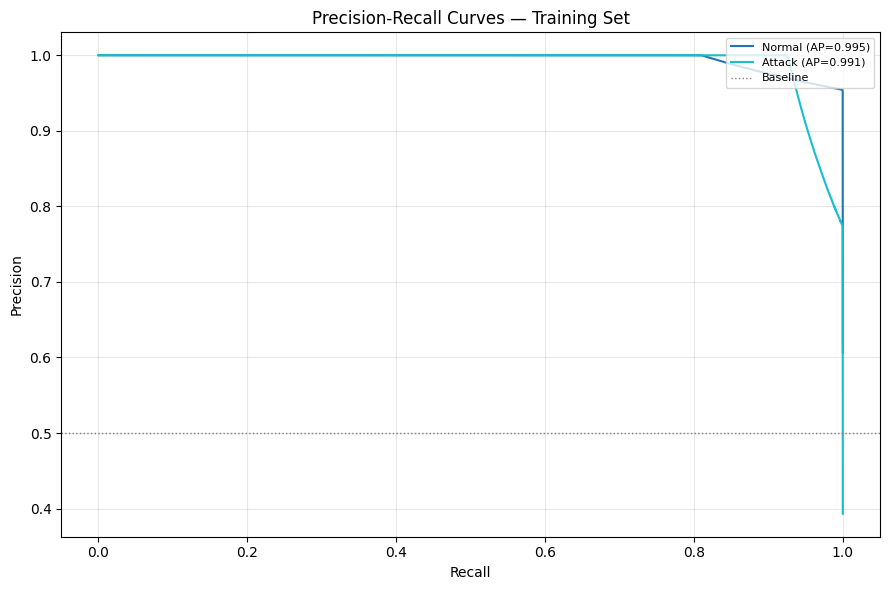

Macro PR-AUC (Training Set): 0.9930

=== Precision-Recall Curves — TEST SET ===


/tmp/ipykernel_57/2376690815.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n)


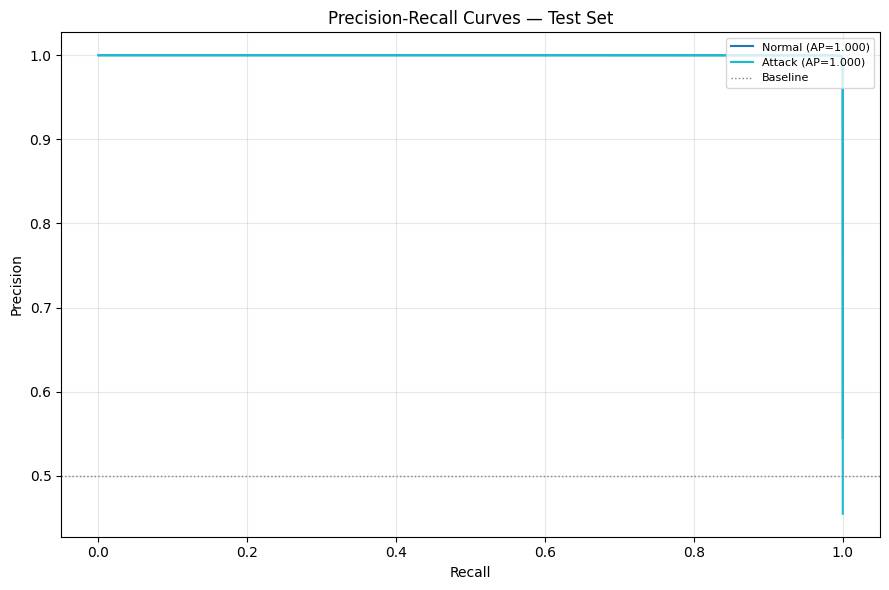

Macro PR-AUC (Test Set): 1.0000

Macro PR-AUC (Test Set, direct): 1.0000


In [44]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

def plot_pr_curves(y_bin, y_prob_arr, class_names, split_name):
    """Plot per-class and macro-average Precision-Recall curves."""
    n = len(class_names)
    colors = plt.cm.get_cmap('tab10', n)

    pr_dict, rc_dict, ap_dict = {}, {}, {}
    for i in range(n):
        pr_dict[i], rc_dict[i], _ = precision_recall_curve(y_bin[:, i], y_prob_arr[:, i])
        ap_dict[i] = average_precision_score(y_bin[:, i], y_prob_arr[:, i])

    # Macro average AP
    macro_ap = average_precision_score(y_bin, y_prob_arr, average='macro')

    plt.figure(figsize=(9, 6))
    for i in range(n):
        plt.plot(rc_dict[i], pr_dict[i], color=colors(i), lw=1.5,
                 label=f'{class_names[i]} (AP={ap_dict[i]:.3f})')
    plt.axhline(y=y_bin.mean(), color='gray', linestyle=':', lw=1, label='Baseline')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curves — {split_name}')
    plt.legend(loc='upper right', fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f"Macro PR-AUC ({split_name}): {macro_ap:.4f}")
    return macro_ap

print("\n=== Precision-Recall Curves — TRAINING SET ===")
pr_auc_train = plot_pr_curves(y_train_bin_oh, train_probs, class_names, 'Training Set')

print("\n=== Precision-Recall Curves — TEST SET ===")
pr_auc_macro = plot_pr_curves(y_test_bin_oh,  test_probs,  class_names, 'Test Set')

# ── Macro PR-AUC (standalone, as requested) ───────────────────────────────────
from sklearn.metrics import average_precision_score
pr_auc_macro_check = average_precision_score(y_test_bin_oh, test_probs, average='macro')
print(f"\nMacro PR-AUC (Test Set, direct): {pr_auc_macro_check:.4f}")


## 6. Comprehensive Summary Table

In [45]:
# Create a comprehensive summary table
summary_data = {
    'Metric': [
        # Model Parameters
        'Total Parameters',
        'Trainable Parameters',
        'Non-trainable Parameters',
        'Model Size (KB)',
        'Model Size (MB)',
        '',
        # Dataset & Noise
        'Training Subset Size',
        'Noise Level (%)',
        'Classification Mode',
        'Number of Output Classes',
        '',
        # Model Configuration
        'Sequence Length',
        'Hidden Size (MGU)',
        'Conv1D Channels',
        'Batch Size',
        'Total Epochs',
        'Learning Rate',
        '',
        # Training Performance
        'Total Training Time (sec)',
        'Total Training Time (min)',
        'Average Time per Epoch (sec)',
        'Final Train Accuracy (%)',
        'Final Validation Accuracy (%)',
        'Final Train Loss',
        'Final Validation Loss',
        '',
        # Inference Performance
        'Total Inference Time (sec)',
        'Number of Test Samples',
        'Average Time per Sample (ms)',
        '',
        # Evaluation Metrics
        'Overall Test Accuracy (%)',
        'Device Used'
    ],
    'Value': [
        # Model Parameters
        f'{total_params:,}',
        f'{trainable_params:,}',
        f'{total_params - trainable_params:,}',
        f'{model_size_kb:.2f}',
        f'{model_size_mb:.4f}',
        '',
        # Dataset & Noise
        f'{X_train.shape[0]:,}',
        f'{NOISE_LEVEL*100:.1f}%',
        'Binary (Attack vs Normal)' if BINARY_MODE else 'Multiclass',
        f'{output_size}',
        '',
        # Model Configuration
        f'{SEQ_LENGTH}',
        f'{HIDDEN_SIZE}',
        f'{CONV_CHANNELS}',
        f'{BATCH_SIZE}',
        f'{EPOCHS}',
        f'{LEARNING_RATE}',
        '',
        # Training Performance
        f'{training_time:.2f}',
        f'{training_time/60:.2f}',
        f'{training_time/EPOCHS:.2f}',
        f'{history["train_accuracy"][-1]:.2f}',
        f'{history["val_accuracy"][-1]:.2f}',
        f'{history["train_losses"][-1]:.4f}',
        f'{history["val_losses"][-1]:.4f}',
        '',
        # Inference Performance
        f'{inference_time:.2f}',
        f'{len(predictions)}',
        f'{inference_time/len(predictions)*1000:.2f}',
        '',
        # Evaluation Metrics
        f'{accuracy_score(true_labels, predictions)*100:.2f}',
        f'{device}'
    ]
}

summary_df = pd.DataFrame(summary_data)

print("\n" + "="*70)
print("COMPREHENSIVE MODEL SUMMARY TABLE")
print("="*70)
display(summary_df)
print("="*70)


COMPREHENSIVE MODEL SUMMARY TABLE


,Metric,Value
0,Total Parameters,"21,986"
1,Trainable Parameters,"21,986"
2,Non-trainable Parameters,0
3,Model Size (KB),91.49
4,Model Size (MB),0.0893
5,,
6,Training Subset Size,"3,590,143"
7,Noise Level (%),0.0%
8,Classification Mode,Binary (Attack vs Normal)
9,Number of Output Classes,2
